In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)

if "Weight" in df.columns:
    df = df.drop(columns=["Weight"])

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# df.head()

In [3]:
# time periods for splitting

TRAIN_START = pd.Timestamp("2021-03-22")
TRAIN_END   = pd.Timestamp("2024-03-20")

VAL_START   = pd.Timestamp("2024-03-21")
VAL_END     = pd.Timestamp("2025-03-20")

UNSEEN_START = pd.Timestamp("2025-03-21")
UNSEEN_END   = pd.Timestamp("2026-03-20")

In [4]:
# keep only stocks that have data in all 3 periods to avoid unseen stock issues

train_symbols = set(df.loc[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END), "Symbol"].unique())
val_symbols = set(df.loc[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END), "Symbol"].unique())
unseen_symbols = set(df.loc[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END), "Symbol"].unique())

common_symbols = sorted(train_symbols & val_symbols & unseen_symbols)

df = df[df["Symbol"].isin(common_symbols)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Common stocks:", df["Symbol"].nunique())

Common stocks: 499


In [5]:
# split into train/val/unseen

train_df = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_df = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()
unseen_df = df[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END)].copy()

print("Train stocks:", train_df["Symbol"].nunique())
print("Val stocks:", val_df["Symbol"].nunique())
print("Unseen stocks:", unseen_df["Symbol"].nunique())

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Unseen shape:", unseen_df.shape)

Train stocks: 499
Val stocks: 499
Unseen stocks: 499
Train shape: (374800, 9)
Val shape: (124750, 9)
Unseen shape: (125248, 9)


In [6]:
# export and remove unseen

unseen_df.to_csv("data/unseen_holdout_raw.csv", index=False)

df = pd.concat([train_df, val_df], axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Model dataframe shape:", df.shape)
print("Train + Val Date range:", df["Date"].min(), "to", df["Date"].max())

df_raw_dev = df.copy()

Model dataframe shape: (499550, 9)
Train + Val Date range: 2021-03-22 00:00:00 to 2025-03-20 00:00:00


In [7]:
# feature engineering function

import numpy as np

def engineer_features(panel_df):
    panel_df = panel_df.copy()
    panel_df = panel_df.sort_values(["Symbol", "Date"])

    g = panel_df.groupby("Symbol")

    # simple 1 day return
    panel_df["ret_1"] = g["Close"].pct_change()

    # target: std of stock's daily returns from t+1 to t+21
    panel_df["target_vol_21d"] = (
        g["ret_1"].transform(lambda s: s.shift(-1).rolling(21).std().shift(-20))
    )

    # today's absolute return
    panel_df["ret_abs_1"] = panel_df["ret_1"].abs()

    # std of returns over past 5, 10, 21 days
    for w in [5, 10, 21]:
        panel_df[f"ret_std_{w}"] = g["ret_1"].transform(lambda s: s.rolling(w).std())

    # daily intraday range
    panel_df["hl_range"] = (panel_df["High"] - panel_df["Low"]) / panel_df["Close"]

    for w in [5, 21]:
        panel_df[f"hl_range_mean_{w}"] = g["hl_range"].transform(lambda s: s.rolling(w).mean())

    # relative volume
    for w in [5, 21]:
        panel_df[f"vol_mean_{w}"] = g["Volume"].transform(lambda s: s.rolling(w).mean())
        panel_df[f"vol_rel_{w}"] = panel_df["Volume"] / panel_df[f"vol_mean_{w}"]

    return panel_df


In [8]:
# apply feature engineering to dev set
df = engineer_features(df)

feature_cols = [
    "ret_1",
    "ret_abs_1",
    "ret_std_5",
    "ret_std_10",
    "ret_std_21",
    "hl_range",
    "hl_range_mean_5",
    "hl_range_mean_21",
    "vol_rel_5",
    "vol_rel_21",
]

target_col = "target_vol_21d"


In [9]:
# just look at features and target for now

df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol', 'Security',
       'Sector', 'ret_1', 'target_vol_21d', 'ret_abs_1', 'ret_std_5',
       'ret_std_10', 'ret_std_21', 'hl_range', 'hl_range_mean_5',
       'hl_range_mean_21', 'vol_mean_5', 'vol_rel_5', 'vol_mean_21',
       'vol_rel_21'],
      dtype='object')

In [10]:
# create train/val sets for modeling

LOOKBACK = 21
HORIZON = 21

# drop missing / non-finite once
df_feat = df.dropna(subset=feature_cols + [target_col]).copy()
finite_mask = np.isfinite(df_feat[feature_cols + [target_col]]).all(axis=1)
df_feat = df_feat.loc[finite_mask].copy()

# keep rows whose endpoint date is in the split
# AND whose forward target window stays inside the split
#
# because target at date t uses returns from t+1 ... t+21

# use per-symbol forward availability instead of calendar days
df_feat = df_feat.sort_values(["Symbol", "Date"]).copy()
g = df_feat.groupby("Symbol")

# next date after horizon steps, used only as a guard
df_feat["date_plus_horizon"] = g["Date"].shift(-HORIZON)

# training rows: endpoint in train, and full forward target remains in train
train_feat = df_feat[
    (df_feat["Date"] >= TRAIN_START) &
    (df_feat["Date"] <= TRAIN_END) &
    (df_feat["date_plus_horizon"].notna()) &
    (df_feat["date_plus_horizon"] <= TRAIN_END)
].copy()

# validation rows: endpoint in val, and full forward target remains in val
val_feat = df_feat[
    (df_feat["Date"] >= VAL_START) &
    (df_feat["Date"] <= VAL_END) &
    (df_feat["date_plus_horizon"].notna()) &
    (df_feat["date_plus_horizon"] <= VAL_END)
].copy()

print("train_feat:", train_feat.shape)
print("val_feat:", val_feat.shape)


train_feat: (353821, 23)
val_feat: (103781, 23)


In [11]:
LOOKBACK = 21

def make_sequences(panel_df, feature_cols, target_col, lookback=21):
    X_list = []
    y_list = []
    meta_list = []

    panel_df = panel_df.sort_values(["Symbol", "Date"]).copy()

    for symbol, g in panel_df.groupby("Symbol"):
        g = g.sort_values("Date").reset_index(drop=True)

        X_values = g[feature_cols].to_numpy(dtype=np.float32)
        y_values = g[target_col].to_numpy(dtype=np.float32)
        dates = g["Date"].to_numpy()

        for t in range(lookback - 1, len(g)):
            X_window = X_values[t - lookback + 1 : t + 1]
            y_target = y_values[t]
            end_date = dates[t]

            if not np.isfinite(X_window).all():
                continue
            if not np.isfinite(y_target):
                continue

            X_list.append(X_window)
            y_list.append(y_target)
            meta_list.append({
                "Symbol": symbol,
                "Date": end_date
            })

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta

In [12]:
# train sequences
X_train, y_train, meta_train = make_sequences(
    train_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_train["Date"] = pd.to_datetime(meta_train["Date"])

print("Train:", X_train.shape, y_train.shape)

# validation sequences with train context
train_context = (
    train_feat
    .sort_values(["Symbol", "Date"])
    .groupby("Symbol", group_keys=False)
    .tail(LOOKBACK - 1)
    .copy()
)

val_with_context = (
    pd.concat([train_context, val_feat], axis=0)
    .sort_values(["Symbol", "Date"])
    .drop_duplicates(subset=["Symbol", "Date"], keep="last")
    .reset_index(drop=True)
)

X_val_all, y_val_all, meta_val_all = make_sequences(
    val_with_context,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_val_all["Date"] = pd.to_datetime(meta_val_all["Date"])

val_keep = (
    (meta_val_all["Date"] >= VAL_START) &
    (meta_val_all["Date"] <= VAL_END)
)

X_val = X_val_all[val_keep.values]
y_val = y_val_all[val_keep.values]
meta_val = meta_val_all.loc[val_keep].reset_index(drop=True)

print("Val:", X_val.shape, y_val.shape)

Train: (343841, 21, 10) (343841,)
Val: (103781, 21, 10) (103781,)


In [13]:
# scale features and target using train only

n_features = X_train.shape[2]

train_2d = X_train.reshape(-1, n_features)
feature_means = train_2d.mean(axis=0)
feature_stds = train_2d.std(axis=0) + 1e-8

X_train_scaled = (X_train - feature_means) / feature_stds
X_val_scaled = (X_val - feature_means) / feature_stds

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std

In [14]:
# build model

keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(feature_cols))),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# train

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 0.4264 - mae: 0.4421 - val_loss: 0.5880 - val_mae: 0.5003
Epoch 2/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.3964 - mae: 0.4288 - val_loss: 0.5891 - val_mae: 0.4941
Epoch 3/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.3794 - mae: 0.4227 - val_loss: 0.5948 - val_mae: 0.4967
Epoch 4/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.3670 - mae: 0.4179 - val_loss: 0.6003 - val_mae: 0.4980
Epoch 5/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.3559 - mae: 0.4138 - val_loss: 0.5999 - val_mae: 0.4968
Epoch 6/100
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.3457 - mae: 0.4102 - val_loss: 0.6008 - val_mae: 0.4953


In [16]:
val_pred_scaled = model.predict(X_val_scaled).reshape(-1)
val_pred = val_pred_scaled * y_std + y_mean

val_results = meta_val.copy()
val_results["y_true"] = y_val
val_results["y_pred"] = val_pred

val_results.head()

3244/3244 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


,Symbol,Date,y_true,y_pred
0,A,2024-03-21,0.014448,0.016827
1,A,2024-03-22,0.017340,0.016258
2,A,2024-03-25,0.017325,0.017528
3,A,2024-03-26,0.017329,0.017786
4,A,2024-03-27,0.016776,0.017085


In [17]:
# compute valuation metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(val_results["y_true"], val_results["y_pred"]))
mae = mean_absolute_error(val_results["y_true"], val_results["y_pred"])

print("Validation RMSE:", rmse)
print("Validation MAE:", mae)

Validation RMSE: 0.007257508416845338
Validation MAE: 0.004735374357551336


In [18]:
# check correlation

corr = val_results["y_true"].corr(val_results["y_pred"])
print("Validation correlation:", corr)

Validation correlation: 0.5976208524426329


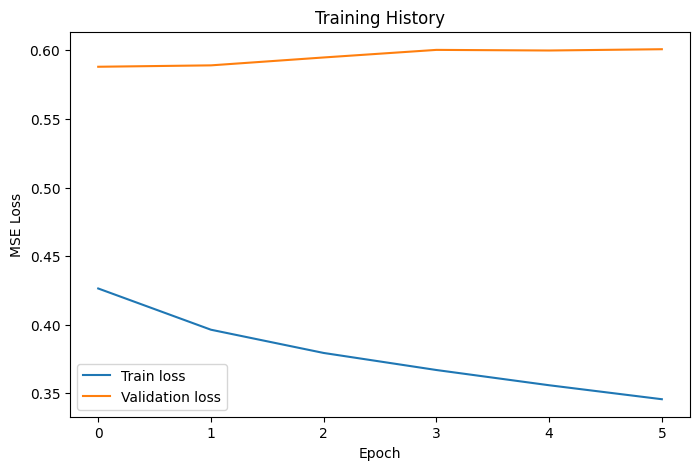

In [19]:
# plot training curve

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

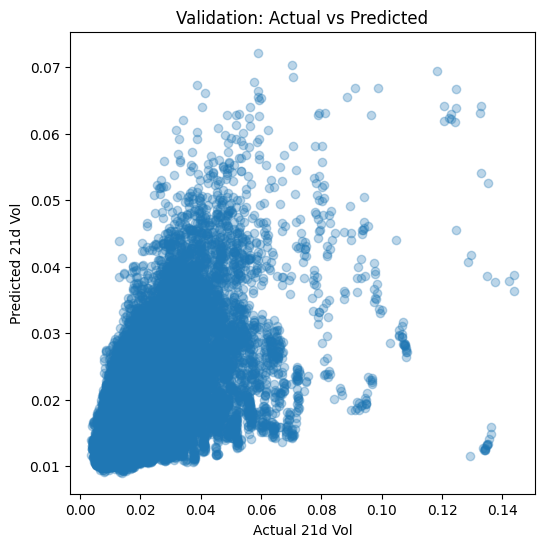

In [20]:
# plot actual vs predicted

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(val_results["y_true"], val_results["y_pred"], alpha=0.3)
plt.xlabel("Actual 21d Vol")
plt.ylabel("Predicted 21d Vol")
plt.title("Validation: Actual vs Predicted")
plt.show()

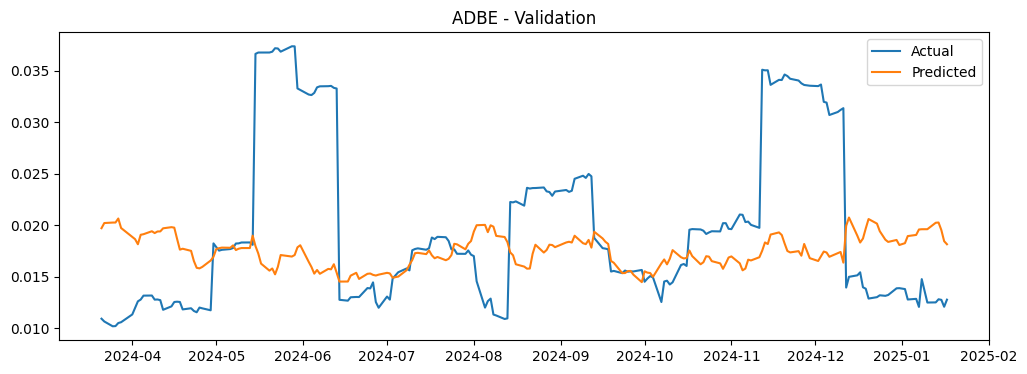

In [21]:
# inspect predictions for a sample stock

sample_symbol = val_results["Symbol"].iloc[1650]

tmp = val_results[val_results["Symbol"] == sample_symbol].sort_values("Date")

plt.figure(figsize=(12, 4))
plt.plot(tmp["Date"], tmp["y_true"], label="Actual")
plt.plot(tmp["Date"], tmp["y_pred"], label="Predicted")
plt.title(f"{sample_symbol} - Validation")
plt.legend()
plt.show()

In [22]:
# baseline comparison - use past 21d volatility as naive predictor

baseline_results = meta_val.copy()
baseline_results = baseline_results.merge(
    val_feat[["Symbol", "Date", "ret_std_21", target_col]],
    on=["Symbol", "Date"],
    how="left"
)

baseline_results["baseline_pred"] = baseline_results["ret_std_21"]
baseline_results["y_true"] = baseline_results[target_col]

baseline_rmse = np.sqrt(mean_squared_error(
    baseline_results["y_true"],
    baseline_results["baseline_pred"]
))
baseline_mae = mean_absolute_error(
    baseline_results["y_true"],
    baseline_results["baseline_pred"]
)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 0.009551354546655235
Baseline MAE: 0.006199224649093266


In [23]:
val_results = meta_val.copy()
val_results["y_true"] = y_val
val_results["y_pred"] = val_pred

baseline_map = val_feat[["Symbol", "Date", "ret_std_21"]].copy()
val_results = val_results.merge(baseline_map, on=["Symbol", "Date"], how="left")
val_results["baseline_pred"] = val_results["ret_std_21"]

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rows = []
for symbol, g in val_results.groupby("Symbol"):
    if len(g) < 5:
        continue
    rows.append({
        "Symbol": symbol,
        "rmse_lstm": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_lstm": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "n": len(g)
    })

by_stock = pd.DataFrame(rows)
by_stock["rmse_win"] = by_stock["rmse_lstm"] < by_stock["rmse_baseline"]
by_stock["mae_win"] = by_stock["mae_lstm"] < by_stock["mae_baseline"]

print("Pct stocks where LSTM wins on RMSE:", by_stock["rmse_win"].mean())
print("Pct stocks where LSTM wins on MAE:", by_stock["mae_win"].mean())

by_stock.head()

Pct stocks where LSTM wins on RMSE: 0.8857715430861723
Pct stocks where LSTM wins on MAE: 0.8597194388777555


,Symbol,rmse_lstm,rmse_baseline,mae_lstm,mae_baseline,n,rmse_win,mae_win
0,A,0.005022,0.005941,0.004249,0.005041,208,True,True
1,AAPL,0.005184,0.005028,0.004306,0.003979,208,False,False
2,ABBV,0.007589,0.010069,0.005320,0.006817,208,True,True
3,ABNB,0.007501,0.010866,0.005074,0.008507,208,True,True
4,ABT,0.004585,0.005231,0.003887,0.004335,208,True,True


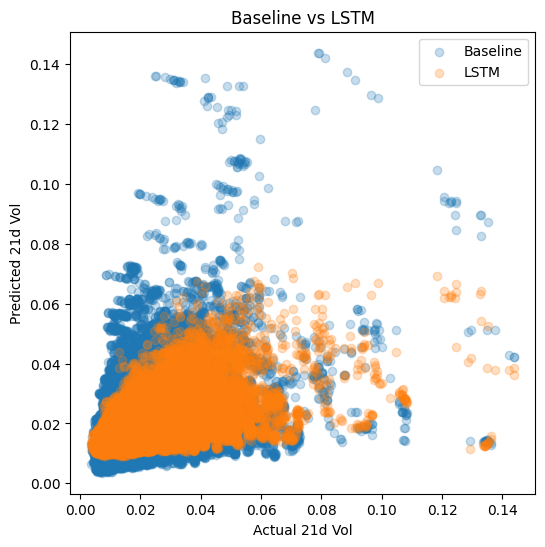

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(val_results["y_true"], val_results["baseline_pred"], alpha=0.25, label="Baseline")
plt.scatter(val_results["y_true"], val_results["y_pred"], alpha=0.25, label="LSTM")
plt.xlabel("Actual 21d Vol")
plt.ylabel("Predicted 21d Vol")
plt.title("Baseline vs LSTM")
plt.legend()
plt.show()

In [26]:
print("LSTM corr:", val_results["y_true"].corr(val_results["y_pred"]))
print("Baseline corr:", val_results["y_true"].corr(val_results["baseline_pred"]))

LSTM corr: 0.5976208524426329
Baseline corr: 0.4379502687275839


In [27]:
# unseen setup: build raw context first, then engineer features

unseen_df = pd.read_csv("data/unseen_holdout_raw.csv")

unseen_df["Date"] = pd.to_datetime(unseen_df["Date"])
unseen_df = unseen_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(unseen_df["Date"].min(), unseen_df["Date"].max())
print(unseen_df.shape)
print("Stocks:", unseen_df["Symbol"].nunique())

# IMPORTANT:
# use the RAW dev dataframe here, not the cleaned modeling dataframe
# this raw dev dataframe should be the train+val OHLCV panel before feature engineering/dropna
#
# If your raw dev dataframe is currently called df_raw_dev, use that.
# If not, create it earlier and keep it unchanged.

dev_context_raw = (
    df_raw_dev
    .sort_values(["Symbol", "Date"])
    .groupby("Symbol", group_keys=False)
    .tail(LOOKBACK - 1)
    .copy()
)

unseen_raw_with_context = (
    pd.concat([dev_context_raw, unseen_df], axis=0)
    .sort_values(["Symbol", "Date"])
    .drop_duplicates(subset=["Symbol", "Date"], keep="last")
    .reset_index(drop=True)
)

# engineer features AFTER raw context is appended
unseen_feat_all = engineer_features(unseen_raw_with_context)

# keep only actual unseen rows
unseen_feat = unseen_feat_all[
    (unseen_feat_all["Date"] >= UNSEEN_START) &
    (unseen_feat_all["Date"] <= UNSEEN_END)
].copy()

unseen_feat = unseen_feat.dropna(subset=feature_cols + [target_col]).copy()
finite_mask = np.isfinite(unseen_feat[feature_cols + [target_col]]).all(axis=1)
unseen_feat = unseen_feat.loc[finite_mask].copy()

print("unseen_feat:", unseen_feat.shape)

2025-03-21 00:00:00 2026-03-20 00:00:00
(125248, 9)
Stocks: 499
unseen_feat: (114270, 22)


In [28]:
# unseen sequences from engineered panel that already includes raw dev context
X_unseen_all, y_unseen_all, meta_unseen_all = make_sequences(
    unseen_feat_all,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

meta_unseen_all["Date"] = pd.to_datetime(meta_unseen_all["Date"])

unseen_keep = (
    (meta_unseen_all["Date"] >= UNSEEN_START) &
    (meta_unseen_all["Date"] <= UNSEEN_END)
)

X_unseen = X_unseen_all[unseen_keep.values]
y_unseen = y_unseen_all[unseen_keep.values]
meta_unseen = meta_unseen_all.loc[unseen_keep].reset_index(drop=True)

print("Unseen:", X_unseen.shape, y_unseen.shape)

Unseen: (104290, 21, 10) (104290,)


In [29]:
# scale unseen using train only

X_unseen_scaled = (X_unseen - feature_means) / feature_stds

# predict on unseen

unseen_pred_scaled = model.predict(X_unseen_scaled).reshape(-1)
unseen_pred = unseen_pred_scaled * y_std + y_mean

3260/3260 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [30]:
unseen_results = meta_unseen.copy()
unseen_results["y_true"] = y_unseen
unseen_results["y_pred"] = unseen_pred

In [31]:
baseline_map_unseen = unseen_feat[["Symbol", "Date", "ret_std_21"]].copy()

unseen_results = unseen_results.merge(
    baseline_map_unseen,
    on=["Symbol", "Date"],
    how="left"
)

unseen_results["baseline_pred"] = unseen_results["ret_std_21"]

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

unseen_rmse = np.sqrt(mean_squared_error(unseen_results["y_true"], unseen_results["y_pred"]))
unseen_mae = mean_absolute_error(unseen_results["y_true"], unseen_results["y_pred"])
unseen_corr = unseen_results["y_true"].corr(unseen_results["y_pred"])

baseline_unseen_rmse = np.sqrt(mean_squared_error(unseen_results["y_true"], unseen_results["baseline_pred"]))
baseline_unseen_mae = mean_absolute_error(unseen_results["y_true"], unseen_results["baseline_pred"])
baseline_unseen_corr = unseen_results["y_true"].corr(unseen_results["baseline_pred"])

print("UNSEEN LSTM RMSE:", unseen_rmse)
print("UNSEEN LSTM MAE:", unseen_mae)
print("UNSEEN LSTM corr:", unseen_corr)

print("UNSEEN Baseline RMSE:", baseline_unseen_rmse)
print("UNSEEN Baseline MAE:", baseline_unseen_mae)
print("UNSEEN Baseline corr:", baseline_unseen_corr)

UNSEEN LSTM RMSE: 0.007574060046651667
UNSEEN LSTM MAE: 0.005194149911403656
UNSEEN LSTM corr: 0.5736168212269257
UNSEEN Baseline RMSE: 0.010426150222109593
UNSEEN Baseline MAE: 0.006896895107065282
UNSEEN Baseline corr: 0.41953239989333607


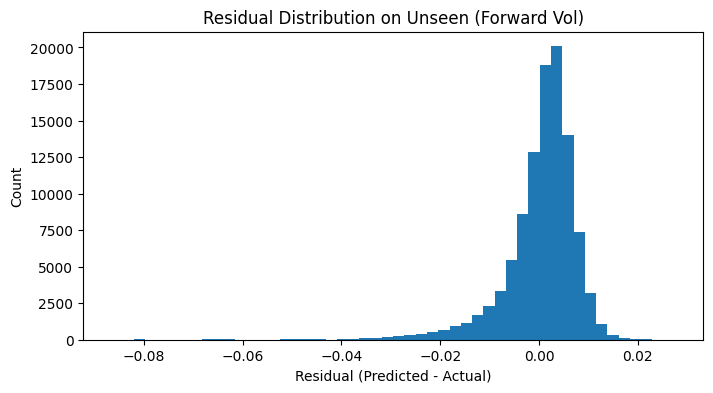

In [33]:
unseen_results["error"] = unseen_results["y_pred"] - unseen_results["y_true"]
unseen_residuals = unseen_results["error"]

plt.figure(figsize=(8, 4))
plt.hist(unseen_residuals, bins=50)
plt.title("Residual Distribution on Unseen (Forward Vol)")
plt.xlabel("Residual (Predicted - Actual)")
plt.ylabel("Count")
plt.show()

In [34]:
# results

unseen_results = meta_unseen.copy()
unseen_results["y_true"] = y_unseen
unseen_results["y_pred"] = unseen_pred

In [35]:
unseen_results = unseen_results.merge(
    unseen_feat[["Symbol", "Date", "ret_std_21", "Sector"]],
    on=["Symbol", "Date"],
    how="left"
)

unseen_results["baseline_pred"] = unseen_results["ret_std_21"]

In [36]:
# stock-level insights

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rows = []
for symbol, g in unseen_results.groupby("Symbol"):
    if len(g) < 5:
        continue
    rows.append({
        "Symbol": symbol,
        "rmse_lstm": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_lstm": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "corr_lstm": g["y_true"].corr(g["y_pred"]),
        "corr_baseline": g["y_true"].corr(g["baseline_pred"]),
        "n_obs": len(g)
    })

by_stock = pd.DataFrame(rows)
by_stock["rmse_win"] = by_stock["rmse_lstm"] < by_stock["rmse_baseline"]
by_stock["mae_win"] = by_stock["mae_lstm"] < by_stock["mae_baseline"]
by_stock["corr_win"] = by_stock["corr_lstm"] > by_stock["corr_baseline"]

print("Pct stocks where LSTM wins on RMSE:", by_stock["rmse_win"].mean())
print("Pct stocks where LSTM wins on MAE:", by_stock["mae_win"].mean())
print("Pct stocks where LSTM wins on corr:", by_stock["corr_win"].mean())

Pct stocks where LSTM wins on RMSE: 0.9018036072144289
Pct stocks where LSTM wins on MAE: 0.8697394789579158
Pct stocks where LSTM wins on corr: 0.6352705410821643


In [38]:
rows = []
for sector, g in unseen_results.groupby("Sector"):
    if len(g) < 20:
        continue
    rows.append({
        "Sector": sector,
        "rmse_lstm": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_lstm": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "corr_lstm": g["y_true"].corr(g["y_pred"]),
        "corr_baseline": g["y_true"].corr(g["baseline_pred"]),
        "n_obs": len(g)
    })

by_sector = pd.DataFrame(rows)
by_sector["rmse_win"] = by_sector["rmse_lstm"] < by_sector["rmse_baseline"]
by_sector["mae_win"] = by_sector["mae_lstm"] < by_sector["mae_baseline"]
by_sector["corr_win"] = by_sector["corr_lstm"] > by_sector["corr_baseline"]

by_sector.sort_values("rmse_lstm")

,Sector,rmse_lstm,rmse_baseline,mae_lstm,mae_baseline,corr_lstm,corr_baseline,n_obs,rmse_win,mae_win,corr_win
10,Utilities,0.005326,0.006176,0.004105,0.003712,0.782959,0.693220,6479,True,False,True
3,Energy,0.005383,0.008388,0.004354,0.005581,0.524105,0.353205,4598,True,True,True
9,Real Estate,0.005595,0.006567,0.004238,0.004749,0.399338,0.319492,6479,True,True,True
2,Consumer Staples,0.005929,0.008183,0.004176,0.005442,0.470050,0.255887,7524,True,True,True
6,Industrials,0.006504,0.009274,0.004800,0.006568,0.493915,0.315376,16302,True,True,True
8,Materials,0.006564,0.009211,0.004942,0.006643,0.616062,0.453301,5434,True,True,True
4,Financials,0.006883,0.009395,0.004781,0.005934,0.549260,0.416915,15883,True,True,True
1,Consumer Discretionary,0.007141,0.010438,0.005085,0.007353,0.547642,0.353176,10032,True,True,True
5,Health Care,0.009231,0.012948,0.006096,0.008634,0.424217,0.224200,12331,True,True,True
7,Information Technology,0.009955,0.013554,0.006821,0.009590,0.561147,0.389072,14421,True,True,True


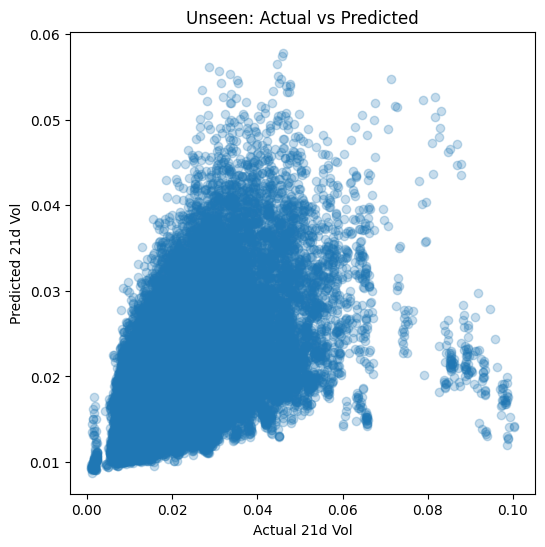

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(unseen_results["y_true"], unseen_results["y_pred"], alpha=0.25)
plt.xlabel("Actual 21d Vol")
plt.ylabel("Predicted 21d Vol")
plt.title("Unseen: Actual vs Predicted")
plt.show()

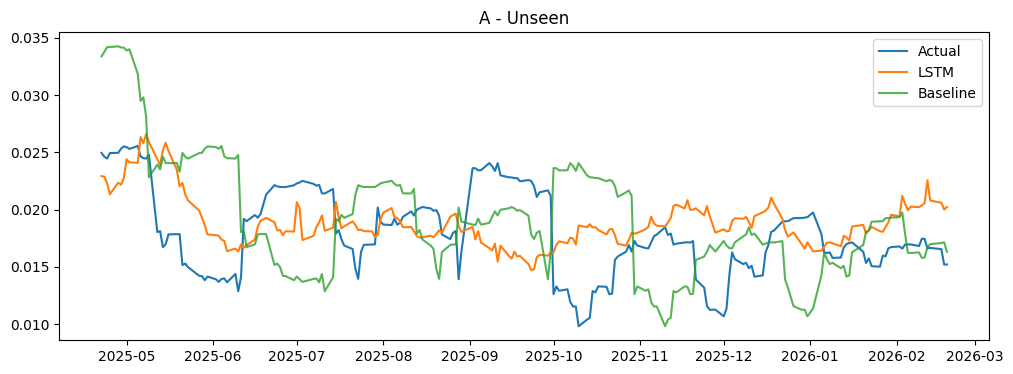

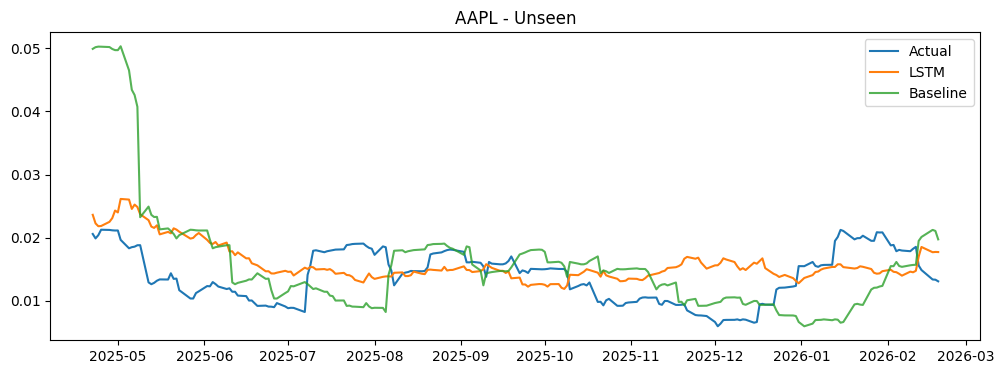

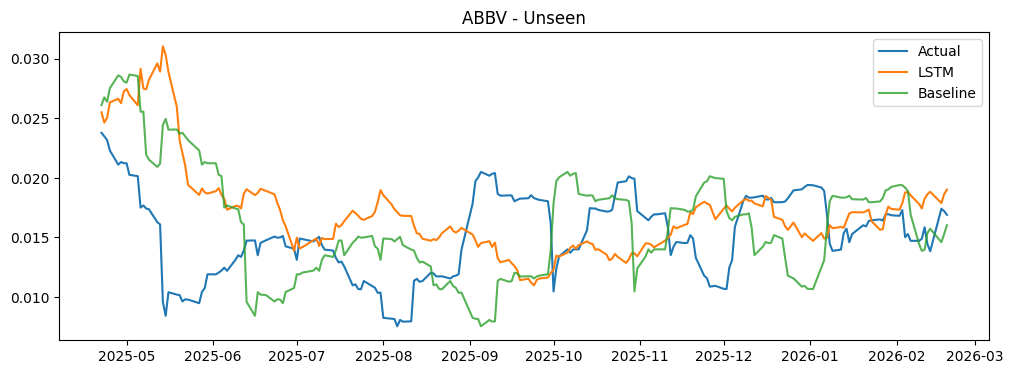

In [40]:
sample_symbols = unseen_results["Symbol"].drop_duplicates().head(3)

for symbol in sample_symbols:
    tmp = unseen_results[unseen_results["Symbol"] == symbol].sort_values("Date")
    plt.figure(figsize=(12, 4))
    plt.plot(tmp["Date"], tmp["y_true"], label="Actual")
    plt.plot(tmp["Date"], tmp["y_pred"], label="LSTM")
    plt.plot(tmp["Date"], tmp["baseline_pred"], label="Baseline", alpha=0.8)
    plt.title(f"{symbol} - Unseen")
    plt.legend()
    plt.show()

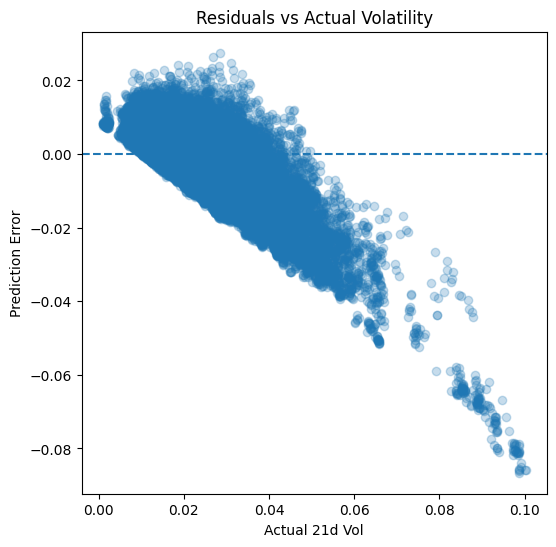

In [41]:
plt.figure(figsize=(6, 6))
error = unseen_results["y_pred"] - unseen_results["y_true"]
plt.scatter(unseen_results["y_true"], error, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual 21d Vol")
plt.ylabel("Prediction Error")
plt.title("Residuals vs Actual Volatility")
plt.show()

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

def evaluate_model(model, X_scaled, y_true, y_mean, y_std):
    pred_scaled = model.predict(X_scaled, verbose=0).reshape(-1)
    pred = pred_scaled * y_std + y_mean
    
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)
    corr = pd.Series(y_true).corr(pd.Series(pred))
    
    return {"rmse": rmse, "mae": mae, "corr": corr}

# baseline validation performance
base_metrics = evaluate_model(model, X_val_scaled, y_val, y_mean, y_std)
print("Base metrics:", base_metrics)

# permutation importance
rng = np.random.default_rng(42)
importance_rows = []

for j, feature in enumerate(feature_cols):
    X_perm = X_val_scaled.copy()

    # shuffle this feature across samples, preserving the 21-step sequence within each sample
    perm_idx = rng.permutation(X_perm.shape[0])
    X_perm[:, :, j] = X_perm[perm_idx, :, j]

    perm_metrics = evaluate_model(model, X_perm, y_val, y_mean, y_std)

    importance_rows.append({
        "feature": feature,
        "rmse_increase": perm_metrics["rmse"] - base_metrics["rmse"],
        "mae_increase": perm_metrics["mae"] - base_metrics["mae"],
        "corr_drop": base_metrics["corr"] - perm_metrics["corr"],
    })

importance_df = pd.DataFrame(importance_rows).sort_values(
    "rmse_increase", ascending=False
)

importance_df

Base metrics: {'rmse': np.float64(0.007257508416845338), 'mae': 0.004735374357551336, 'corr': np.float64(0.5976208524426329)}


,feature,rmse_increase,mae_increase,corr_drop
7,hl_range_mean_21,0.001419,0.001098,0.282241
5,hl_range,0.000639,0.000725,0.096877
6,hl_range_mean_5,0.000306,0.000305,0.043809
4,ret_std_21,0.000231,0.000178,0.035165
2,ret_std_5,0.000186,0.000247,0.008301
1,ret_abs_1,0.000172,0.000271,0.023124
3,ret_std_10,0.000157,0.000152,0.021284
0,ret_1,0.000073,0.000112,0.010083
9,vol_rel_21,0.000053,0.000055,0.008000
8,vol_rel_5,0.000044,0.000146,0.004258


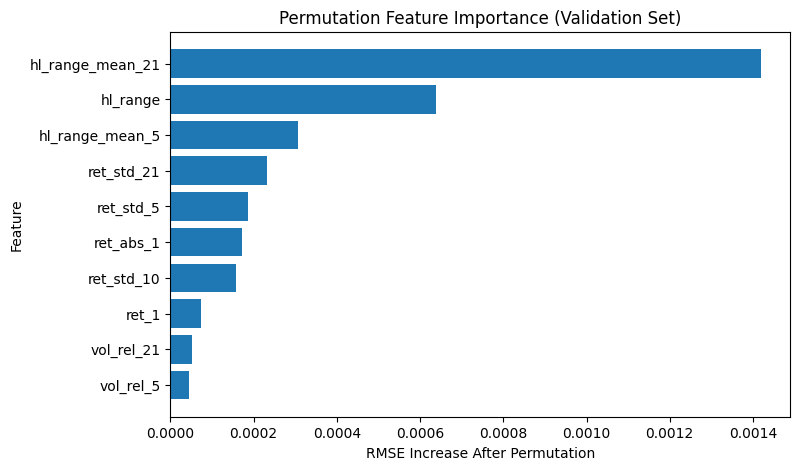

In [43]:
import matplotlib.pyplot as plt

plot_df = importance_df.sort_values("rmse_increase", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["rmse_increase"])
plt.xlabel("RMSE Increase After Permutation")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance (Validation Set)")
plt.show()

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

def evaluate_model(model, X_scaled, y_true, y_mean, y_std):
    pred_scaled = model.predict(X_scaled, verbose=0).reshape(-1)
    pred = pred_scaled * y_std + y_mean

    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)
    corr = pd.Series(y_true).corr(pd.Series(pred))

    return {"rmse": rmse, "mae": mae, "corr": corr}

# baseline unseen performance
base_metrics_unseen = evaluate_model(model, X_unseen_scaled, y_unseen, y_mean, y_std)
print("Base unseen metrics:", base_metrics_unseen)

# permutation importance on unseen
rng = np.random.default_rng(42)
importance_rows_unseen = []

for j, feature in enumerate(feature_cols):
    X_perm = X_unseen_scaled.copy()

    # shuffle this feature across samples, preserving its 21-day sequence within each sample
    perm_idx = rng.permutation(X_perm.shape[0])
    X_perm[:, :, j] = X_perm[perm_idx, :, j]

    perm_metrics = evaluate_model(model, X_perm, y_unseen, y_mean, y_std)

    importance_rows_unseen.append({
        "feature": feature,
        "rmse_increase": perm_metrics["rmse"] - base_metrics_unseen["rmse"],
        "mae_increase": perm_metrics["mae"] - base_metrics_unseen["mae"],
        "corr_drop": base_metrics_unseen["corr"] - perm_metrics["corr"],
    })

importance_unseen_df = pd.DataFrame(importance_rows_unseen).sort_values(
    "rmse_increase", ascending=False
)

importance_unseen_df

Base unseen metrics: {'rmse': np.float64(0.007574060046651667), 'mae': 0.005194149911403656, 'corr': np.float64(0.5736168212269257)}


,feature,rmse_increase,mae_increase,corr_drop
7,hl_range_mean_21,0.001525,0.001266,0.297344
5,hl_range,0.000714,0.000872,0.105082
6,hl_range_mean_5,0.000413,0.000454,0.064429
2,ret_std_5,0.000282,0.000288,0.008960
4,ret_std_21,0.000198,0.000160,0.032736
1,ret_abs_1,0.000188,0.000298,0.022586
3,ret_std_10,0.000160,0.000166,0.024705
0,ret_1,0.000090,0.000151,0.010872
8,vol_rel_5,0.000075,0.000165,0.003313
9,vol_rel_21,0.000031,0.000042,0.003967


In [46]:
importance_compare = importance_df.merge(
    importance_unseen_df,
    on="feature",
    suffixes=("_val", "_unseen")
)

importance_compare = importance_compare.sort_values("rmse_increase_val", ascending=False)
importance_compare

,feature,rmse_increase_val,mae_increase_val,corr_drop_val,rmse_increase_unseen,mae_increase_unseen,corr_drop_unseen
0,hl_range_mean_21,0.001419,0.001098,0.282241,0.001525,0.001266,0.297344
1,hl_range,0.000639,0.000725,0.096877,0.000714,0.000872,0.105082
2,hl_range_mean_5,0.000306,0.000305,0.043809,0.000413,0.000454,0.064429
3,ret_std_21,0.000231,0.000178,0.035165,0.000198,0.000160,0.032736
4,ret_std_5,0.000186,0.000247,0.008301,0.000282,0.000288,0.008960
5,ret_abs_1,0.000172,0.000271,0.023124,0.000188,0.000298,0.022586
6,ret_std_10,0.000157,0.000152,0.021284,0.000160,0.000166,0.024705
7,ret_1,0.000073,0.000112,0.010083,0.000090,0.000151,0.010872
8,vol_rel_21,0.000053,0.000055,0.008000,0.000031,0.000042,0.003967
9,vol_rel_5,0.000044,0.000146,0.004258,0.000075,0.000165,0.003313


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = importance_compare.sort_values("rmse_increase_val", ascending=True)

y_pos = np.arange(len(plot_df))

plt.figure(figsize=(9, 5))
plt.barh(y_pos - 0.2, plot_df["rmse_increase_val"], height=0.4, label="Validation")
plt.barh(y_pos + 0.2, plot_df["rmse_increase_unseen"], height=0.4, label="Unseen")
plt.yticks(y_pos, plot_df["feature"])
plt.xlabel("RMSE Increase After Permutation")
plt.title("Permutation Feature Importance: Validation vs Unseen")
plt.legend()
plt.show()

In [45]:
from sklearn.metrics import r2_score, explained_variance_score

r2 = r2_score(unseen_results["y_true"], unseen_results["y_pred"])
evs = explained_variance_score(unseen_results["y_true"], unseen_results["y_pred"])

print("Unseen R²:", r2)
print("Unseen Explained Variance:", evs)

Unseen R²: 0.3273351788520813
Unseen Explained Variance: 0.32882076501846313


In [47]:
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

rows = []
for symbol, g in unseen_results.groupby("Symbol"):
    if len(g) < 5:
        continue
    
    rows.append({
        "Symbol": symbol,
        "n_obs": len(g),
        "r2_lstm": r2_score(g["y_true"], g["y_pred"]),
        "r2_baseline": r2_score(g["y_true"], g["baseline_pred"]),
        "corr_lstm": g["y_true"].corr(g["y_pred"]),
        "corr_baseline": g["y_true"].corr(g["baseline_pred"])
    })

by_stock_r2 = pd.DataFrame(rows).sort_values("r2_lstm", ascending=False)

by_stock_r2.head(10), by_stock_r2.tail(10)

(    Symbol  n_obs   r2_lstm  r2_baseline  corr_lstm  corr_baseline
 245   INTU    209  0.408302     0.100243   0.675487       0.485695
 478    WDC    209  0.389462     0.073798   0.697947       0.552000
 273   KVUE    209  0.358660    -0.274053   0.653515       0.354593
 225   HOLX    209  0.304316    -0.098261   0.701531       0.457767
 152     EA    209  0.298833    -0.743631   0.677684       0.147448
 139    DIS    209  0.283647    -1.508606   0.570309       0.215807
 111   CPRT    209  0.278034    -0.929786   0.589003      -0.016022
 388   REGN    209  0.264874    -0.560941   0.619552       0.258685
 416    STX    209  0.260638    -0.125687   0.654669       0.442424
 419    SWK    209  0.247499    -1.572054   0.549096       0.457332,
     Symbol  n_obs    r2_lstm  r2_baseline  corr_lstm  corr_baseline
 186     FE    209  -6.583349    -1.983300   0.449430       0.138706
 147    DTE    209  -6.967568    -2.542290   0.350772       0.274498
 102    CNP    209  -7.002748    -2.300775  

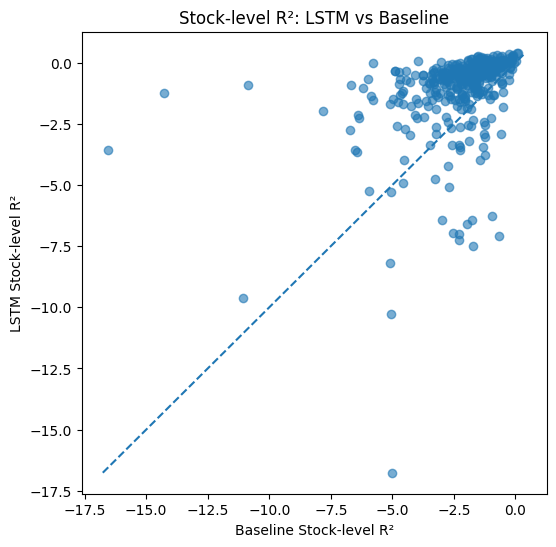

In [48]:
plt.figure(figsize=(6, 6))
plt.scatter(by_stock_r2["r2_baseline"], by_stock_r2["r2_lstm"], alpha=0.6)
lims = [
    min(by_stock_r2["r2_baseline"].min(), by_stock_r2["r2_lstm"].min()),
    max(by_stock_r2["r2_baseline"].max(), by_stock_r2["r2_lstm"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Baseline Stock-level R²")
plt.ylabel("LSTM Stock-level R²")
plt.title("Stock-level R²: LSTM vs Baseline")
plt.show()

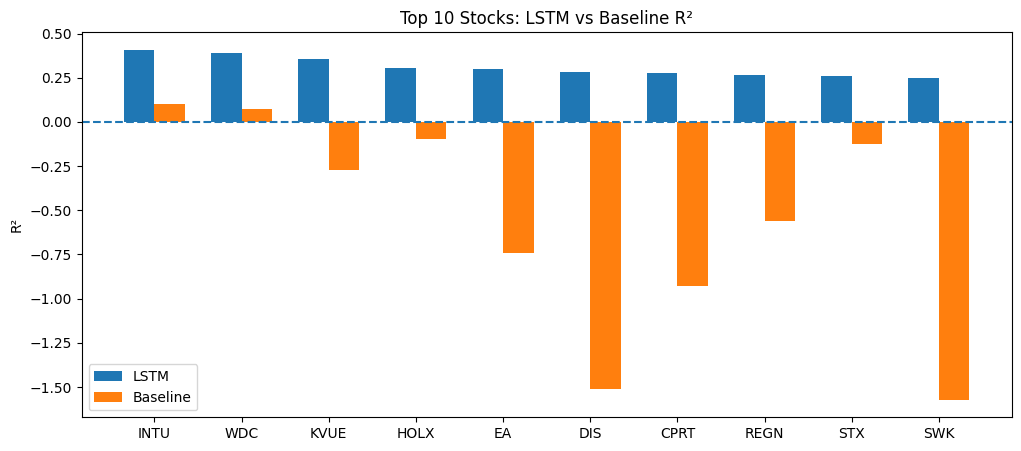

In [49]:
import numpy as np

top10 = by_stock_r2.sort_values("r2_lstm", ascending=False).head(10).copy()

x = np.arange(len(top10))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, top10["r2_lstm"], width, label="LSTM")
plt.bar(x + width/2, top10["r2_baseline"], width, label="Baseline")
plt.axhline(0, linestyle="--")
plt.xticks(x, top10["Symbol"])
plt.ylabel("R²")
plt.title("Top 10 Stocks: LSTM vs Baseline R²")
plt.legend()
plt.show()

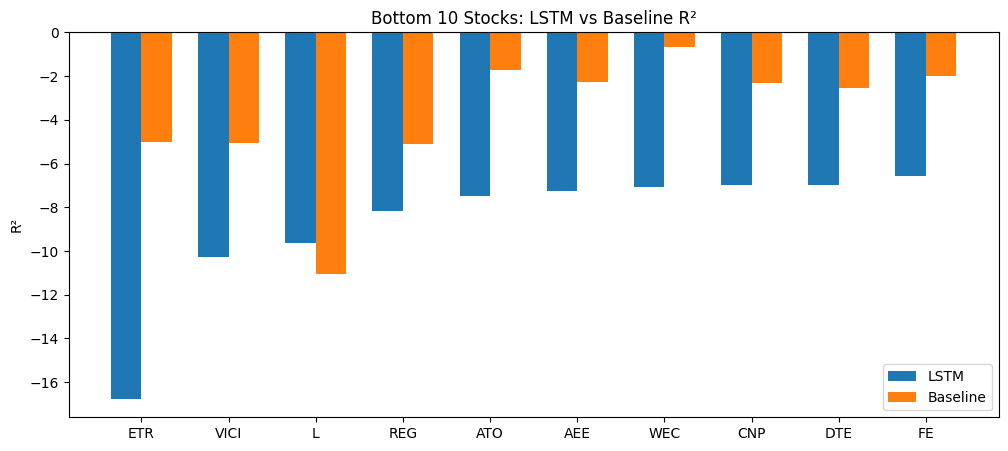

In [50]:
bottom10 = by_stock_r2.sort_values("r2_lstm", ascending=True).head(10).copy()

x = np.arange(len(bottom10))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, bottom10["r2_lstm"], width, label="LSTM")
plt.bar(x + width/2, bottom10["r2_baseline"], width, label="Baseline")
plt.axhline(0, linestyle="--")
plt.xticks(x, bottom10["Symbol"])
plt.ylabel("R²")
plt.title("Bottom 10 Stocks: LSTM vs Baseline R²")
plt.legend()
plt.show()

In [51]:
cluster_df = by_stock_r2.copy()

cluster_df["r2_gain"] = cluster_df["r2_lstm"] - cluster_df["r2_baseline"]
cluster_df["corr_gain"] = cluster_df["corr_lstm"] - cluster_df["corr_baseline"]

cluster_features = [
    "r2_lstm",
    "r2_baseline",
    "corr_lstm",
    "corr_baseline",
    "r2_gain",
    "corr_gain",
]

cluster_data = cluster_df[cluster_features].copy()
cluster_data.head()

,r2_lstm,r2_baseline,corr_lstm,corr_baseline,r2_gain,corr_gain
245,0.408302,0.100243,0.675487,0.485695,0.308059,0.189792
478,0.389462,0.073798,0.697947,0.552000,0.315664,0.145947
273,0.358660,-0.274053,0.653515,0.354593,0.632713,0.298922
225,0.304316,-0.098261,0.701531,0.457767,0.402577,0.243765
152,0.298833,-0.743631,0.677684,0.147448,1.042464,0.530236


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

In [53]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(cluster_data_scaled)

cluster_df[["Symbol", "cluster"] + cluster_features].head()

,Symbol,cluster,r2_lstm,r2_baseline,corr_lstm,corr_baseline,r2_gain,corr_gain
245,INTU,1,0.408302,0.100243,0.675487,0.485695,0.308059,0.189792
478,WDC,1,0.389462,0.073798,0.697947,0.552000,0.315664,0.145947
273,KVUE,1,0.358660,-0.274053,0.653515,0.354593,0.632713,0.298922
225,HOLX,1,0.304316,-0.098261,0.701531,0.457767,0.402577,0.243765
152,EA,1,0.298833,-0.743631,0.677684,0.147448,1.042464,0.530236


In [55]:
cluster_summary = (
    cluster_df
    .groupby("cluster")[cluster_features]
    .mean()
    .round(3)
)

cluster_counts = cluster_df["cluster"].value_counts().sort_index()

print(cluster_summary)
print("\nCluster counts:")
print(cluster_counts)

         r2_lstm  r2_baseline  corr_lstm  corr_baseline  r2_gain  corr_gain
cluster                                                                    
0         -0.780       -1.856     -0.131         -0.116    1.076     -0.014
1         -0.331       -1.421      0.299          0.061    1.090      0.238
2         -6.877       -3.150      0.162          0.077   -3.727      0.085
3         -1.298       -5.321      0.011          0.051    4.024     -0.040

Cluster counts:
cluster
0    243
1    188
2     20
3     48
Name: count, dtype: int64


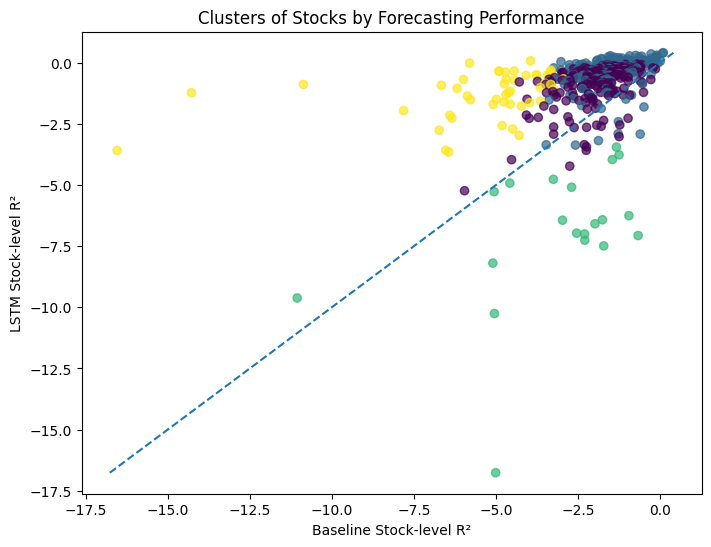

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    cluster_df["r2_baseline"],
    cluster_df["r2_lstm"],
    c=cluster_df["cluster"],
    alpha=0.7
)

lims = [
    min(cluster_df["r2_baseline"].min(), cluster_df["r2_lstm"].min()),
    max(cluster_df["r2_baseline"].max(), cluster_df["r2_lstm"].max())
]
plt.plot(lims, lims, linestyle="--")

plt.xlabel("Baseline Stock-level R²")
plt.ylabel("LSTM Stock-level R²")
plt.title("Clusters of Stocks by Forecasting Performance")
plt.show()

In [57]:
for c in sorted(cluster_df["cluster"].unique()):
    print(f"\nCluster {c}")
    display(
        cluster_df[cluster_df["cluster"] == c]
        .sort_values("r2_lstm", ascending=False)
        [["Symbol", "r2_lstm", "r2_baseline", "corr_lstm", "corr_baseline", "r2_gain", "cluster"]]
        .head(15)
    )


Cluster 0


,Symbol,r2_lstm,r2_baseline,corr_lstm,corr_baseline,r2_gain,cluster
70,BSX,-0.059303,-0.698509,0.002014,0.026218,0.639206,0
467,VRSK,-0.068394,-1.062496,0.040216,-0.179036,0.994102,0
132,DE,-0.078991,-0.562969,-0.020865,0.124556,0.483978,0
58,BF-B,-0.090514,-1.580520,0.006368,-0.255377,1.490007,0
469,VRTX,-0.103333,-1.644608,-0.096126,-0.313401,1.541275,0
36,APD,-0.104997,-1.078830,0.080133,0.174180,0.973832,0
375,POOL,-0.115978,-0.748169,0.025863,-0.092418,0.632190,0
161,EME,-0.123014,-1.406885,0.036186,-0.124328,1.283871,0
496,ZBH,-0.123778,-1.750227,-0.169596,-0.285835,1.626450,0
488,WTW,-0.136301,-0.649007,0.051533,-0.029627,0.512706,0



Cluster 1


,Symbol,r2_lstm,r2_baseline,corr_lstm,corr_baseline,r2_gain,cluster
245,INTU,0.408302,0.100243,0.675487,0.485695,0.308059,1
478,WDC,0.389462,0.073798,0.697947,0.552000,0.315664,1
273,KVUE,0.358660,-0.274053,0.653515,0.354593,0.632713,1
225,HOLX,0.304316,-0.098261,0.701531,0.457767,0.402577,1
152,EA,0.298833,-0.743631,0.677684,0.147448,1.042464,1
139,DIS,0.283647,-1.508606,0.570309,0.215807,1.792253,1
111,CPRT,0.278034,-0.929786,0.589003,-0.016022,1.207820,1
388,REGN,0.264874,-0.560941,0.619552,0.258685,0.825816,1
416,STX,0.260638,-0.125687,0.654669,0.442424,0.386326,1
419,SWK,0.247499,-1.572054,0.549096,0.457332,1.819553,1



Cluster 2


,Symbol,r2_lstm,r2_baseline,corr_lstm,corr_baseline,r2_gain,cluster
377,PPL,-3.451106,-1.329106,0.103546,0.098699,-2.122000,2
331,NI,-3.766737,-1.249630,-0.098511,0.274235,-2.517106,2
283,LNT,-3.959225,-1.452760,0.567475,0.451302,-2.506465,2
127,D,-4.768866,-3.250550,0.480223,0.355566,-1.518316,2
270,KMI,-4.923549,-4.576556,-0.008395,-0.184681,-0.346993,2
296,MCD,-5.089668,-2.695611,-0.229190,-0.090126,-2.394057,2
15,AFL,-5.273736,-5.056306,-0.014782,-0.018558,-0.217430,2
100,CMS,-6.252065,-0.948417,0.489905,0.402255,-5.303649,2
373,PNW,-6.421597,-1.756985,0.028940,-0.035013,-4.664612,2
359,PEG,-6.439332,-2.972197,0.150855,-0.075111,-3.467135,2



Cluster 3


,Symbol,r2_lstm,r2_baseline,corr_lstm,corr_baseline,r2_gain,cluster
297,MCHP,0.078786,-3.944845,0.390511,0.431000,4.023631,3
8,ADI,-0.016905,-5.802558,0.414933,0.273822,5.785652,3
376,PPG,-0.308285,-3.330568,0.110391,0.067596,3.022283,3
55,BBY,-0.340012,-4.444617,0.150296,-0.022630,4.104605,3
398,RTX,-0.343857,-4.907035,0.031095,-0.153403,4.563178,3
344,NXPI,-0.349992,-4.907727,0.034659,0.183890,4.557735,3
130,DD,-0.377001,-3.325290,-0.137128,0.070787,2.948288,3
218,HAS,-0.385329,-4.715107,0.077924,0.206143,4.329778,3
201,GE,-0.425197,-3.358602,0.094431,-0.042979,2.933405,3
57,BEN,-0.494005,-3.762097,0.151353,0.179874,3.268093,3
